# TREC — Classification Run Analysis

Compares `test.csv` (gold labels) against `test_classified.csv` (model predictions)
for a single experiment run, using the standard multiclass metrics.

Set `RUN_DIR` below to point at the run you want to analyze (defaults to the most recent one under `runs/`).

In [1]:
from __future__ import annotations

import ast
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

EXPERIMENT_DIR = Path.cwd()
RUNS_DIR = EXPERIMENT_DIR / "runs"


def _run_config(run_dir: Path) -> dict:
    return json.loads((run_dir / "run_config.json").read_text())


def _has_critics(run_dir: Path) -> bool:
    return _run_config(run_dir)["classifier_config"]["critics"]


def _category_name(run_dir: Path) -> str:
    # run_config's category_name is only set when a run induced categories itself;
    # categories.json is always written (induced or supplied), so read it from there.
    return json.loads((run_dir / "categories.json").read_text())["categories"][0]["name"]


def _gold_column(run_dir: Path) -> str:
    # test_classified.csv carries the gold label through as '{label_column}_gold'.
    return f"{_run_config(run_dir)['label_column']}_gold"


# The debate-analysis sections below only make sense for a `--critics` run, so
# default to the most recent one of those rather than the most recent run
# overall (which may be a plain baseline). Point RUN_DIR at a specific run,
# e.g. RUNS_DIR / "20260914-145645", to override.
all_runs = sorted(d for d in RUNS_DIR.iterdir() if d.is_dir())
critics_runs = [d for d in all_runs if _has_critics(d)]
RUN_DIR = critics_runs[-1] if critics_runs else all_runs[-1]
print(f"Analyzing run: {RUN_DIR.name}")

Analyzing run: 20260914-145645


In [2]:
test = pd.read_csv(RUN_DIR / "test.csv")
classified = pd.read_csv(RUN_DIR / "test_classified.csv")
run_config = _run_config(RUN_DIR)
category = _category_name(RUN_DIR)
gold_col = _gold_column(RUN_DIR)

assert len(test) == len(classified), "row count mismatch between test.csv and test_classified.csv"
assert test[gold_col].equals(classified[gold_col]), "gold labels don't line up between the two files"

print(f"Category: {category!r}  |  gold column: {gold_col!r}  |  rows: {len(classified)}")
classified[["text", gold_col, category]].head()

Category: 'question_type'  |  gold column: 'label_coarse_text_gold'  |  rows: 500


,text,label_coarse_text_gold,question_type
0,How far is it from Denver to Aspen ?,numeric values,"['numeric values', 'locations']"
1,"What county is Modesto , California in ?",locations,['locations']
2,Who was Galileo ?,human beings,"['human beings', 'description and abstract con..."
3,What is an atom ?,description and abstract concepts,['description and abstract concepts']
4,When did Hawaii become a state ?,numeric values,['numeric values']


In [3]:
def first_label(raw: str) -> str:
    labels = ast.literal_eval(raw)
    return labels[0] if labels else "none"


classified["_pred"] = classified[category].apply(first_label)
classified["_initial_pred"] = classified[f"{category}_initial"].apply(first_label)
classified["_n_labels"] = classified[category].apply(lambda raw: len(ast.literal_eval(raw)))

# "none" means the model reached consensus on "no fitting label" — drop it everywhere below.
n_unclassified = (classified["_pred"].str.lower() == "none").sum()
print(f"Dropping {n_unclassified} unclassified rows ({n_unclassified / len(classified):.1%}) from the analysis")
classified = classified[classified["_pred"].str.lower() != "none"].reset_index(drop=True)

n_ambiguous = (classified["_n_labels"] > 1).sum()
print(f"Rows with >1 predicted label: {n_ambiguous} ({n_ambiguous / len(classified):.1%}) — first label used below")

classified["_correct"] = classified["_pred"] == classified[gold_col]
y_true = classified[gold_col]
y_pred = classified["_pred"]
labels_order = sorted(set(y_true) | set(y_pred))

Dropping 0 unclassified rows (0.0%) from the analysis
Rows with >1 predicted label: 95 (19.0%) — first label used below


In [4]:
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.3f}\n")
print(classification_report(y_true, y_pred, labels=labels_order, digits=3, zero_division=0))

Accuracy: 0.860

                                   precision    recall  f1-score   support

                     abbreviation      0.818     1.000     0.900         9
description and abstract concepts      0.763     0.957     0.849       138
                         entities      0.699     0.543     0.611        94
                     human beings      0.983     0.892     0.935        65
                        locations      1.000     0.827     0.905        81
                   numeric values      0.966     1.000     0.983       113

                         accuracy                          0.860       500
                        macro avg      0.871     0.870     0.864       500
                     weighted avg      0.865     0.860     0.856       500



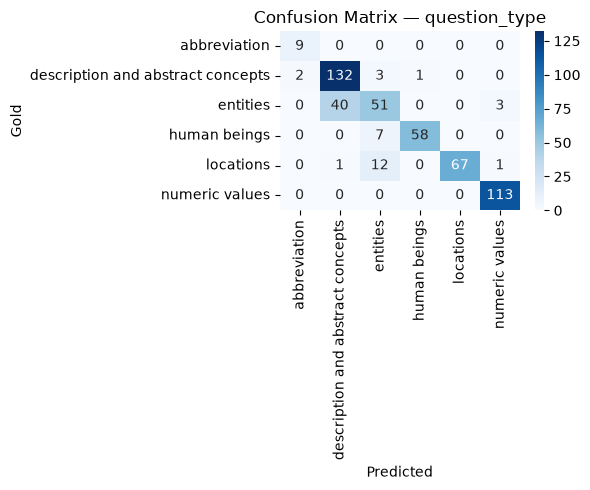

In [5]:
cm = confusion_matrix(y_true, y_pred, labels=labels_order)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predicted")
plt.ylabel("Gold")
plt.title(f"Confusion Matrix — {category}")
plt.tight_layout()
plt.show()

## Critic / Debate Analysis

`--critics` mode samples each row `sampling_runs` times and votes; a row is only
escalated to a Critic (and, if it raises a real challenge, a Reconciler) when the
leading vote falls short of `consensus_threshold` and there's a genuine runner-up.
This looks at how accuracy differs across that split, and whether the critic step
nets out as a fix or a regression when it does change the label.

In [6]:
votes = classified[f"{category}_votes"].apply(json.loads)
threshold = run_config["classifier_config"]["consensus_threshold"]
escalated = votes.apply(lambda v: max(v.values()) < threshold and len(v) >= 2)


def stage_group(esc: bool, challenged: bool, reconciled: bool) -> str:
    if not esc:
        return "Skipped critic (consensus)"
    if not challenged:
        return "Escalated, not challenged"
    if reconciled:
        return "Challenged & reconciled"
    return "Challenged, reconciler failed"


classified["_stage"] = [
    stage_group(e, c, r)
    for e, c, r in zip(escalated, classified[f"{category}_challenged"], classified[f"{category}_reconciled"])
]

print(f"Consensus threshold: {threshold}/{run_config['classifier_config']['sampling_runs']} votes\n")
print(f"Skipped critic loop:     n={(~escalated).sum():5d}  accuracy={classified.loc[~escalated, '_correct'].mean():.3f}")
print(f"Went through critic loop: n={escalated.sum():5d}  accuracy={classified.loc[escalated, '_correct'].mean():.3f}\n")

stage_summary = (
    classified.groupby("_stage")["_correct"]
    .agg(rows="size", accuracy="mean")
    .sort_values("accuracy")
)
stage_summary

Consensus threshold: 4/5 votes

Skipped critic loop:     n=  486  accuracy=0.862
Went through critic loop: n=   14  accuracy=0.786



,rows,accuracy
_stage,,
Challenged & reconciled,8,0.750000
"Escalated, not challenged",6,0.833333
Skipped critic (consensus),486,0.862140


In [7]:
reconciled_mask = classified[f"{category}_reconciled"]
flipped = classified.loc[reconciled_mask, ["_initial_pred", "_pred", gold_col]].copy()
flipped["initial_correct"] = flipped["_initial_pred"] == flipped[gold_col]
flipped["final_correct"] = flipped["_pred"] == flipped[gold_col]

fixed = ((~flipped["initial_correct"]) & flipped["final_correct"]).sum()
broken = (flipped["initial_correct"] & (~flipped["final_correct"])).sum()
unchanged = len(flipped) - fixed - broken

print(f"Reconciled rows (label could have changed): {len(flipped)}")
print(f"  Fixed by critic  (incorrect -> correct): {fixed}")
print(f"  Broken by critic (correct -> incorrect): {broken}")
print(f"  Unchanged outcome:                       {unchanged}")
print(f"  Net effect:                              {fixed - broken:+d}\n")

pd.crosstab(
    flipped["initial_correct"].map({True: "Initial: correct", False: "Initial: incorrect"}),
    flipped["final_correct"].map({True: "Final: correct", False: "Final: incorrect"}),
    margins=True,
    margins_name="Total",
)

Reconciled rows (label could have changed): 8
  Fixed by critic  (incorrect -> correct): 5
  Broken by critic (correct -> incorrect): 1
  Unchanged outcome:                       2
  Net effect:                              +4



final_correct,Final: correct,Final: incorrect,Total
initial_correct,,,
Initial: correct,1,1,2
Initial: incorrect,5,1,6
Total,6,2,8


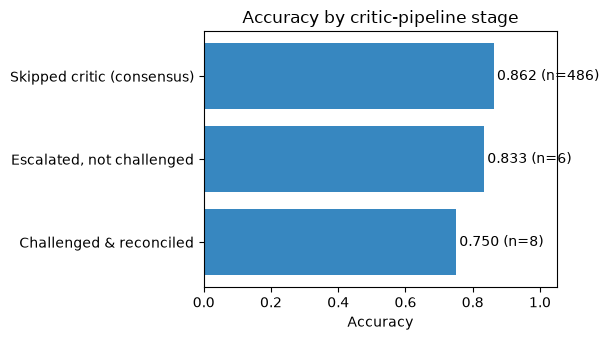

In [8]:
plt.figure(figsize=(6, 3.5))
order = stage_summary.index
bar_color = sns.color_palette("Blues", 5)[3]
plt.barh(order, stage_summary["accuracy"], color=bar_color)
for i, (acc, n) in enumerate(zip(stage_summary["accuracy"], stage_summary["rows"])):
    plt.text(acc + 0.01, i, f"{acc:.3f} (n={n})", va="center")
plt.xlim(0, 1.05)
plt.xlabel("Accuracy")
plt.title("Accuracy by critic-pipeline stage")
plt.tight_layout()
plt.show()

## Comparative Analysis: Critics vs. Baselines

Compares three runs, all classifying the same test split with the same supplied `categories.json`:

| Run | Setup |
|---|---|
| `20260914-145645` | 5 classifiers (self-consistency sampling) + Critic/Reconciler debate |
| `20260914-150203-baseline_1_classifier` | 1 classifier, no critics |
| `20260914-152304-baseline_5_classifiers` | 5 classifiers (plurality vote via `--n-classifiers`), no critics |

Same drop-unclassified-rows rule as above is applied independently within each run.

In [9]:
RUN_SPECS = {
    "Critics (5 classifiers)": "20260914-145645",
    "Baseline (1 classifier)": "20260914-150203-baseline_1_classifier",
    "Baseline (5 classifiers)": "20260914-152304-baseline_5_classifiers",
}
CLASS_LABELS = sorted(test[gold_col].unique())


def load_run_metrics(run_name: str) -> dict:
    run_dir = RUNS_DIR / run_name
    run_df = pd.read_csv(run_dir / "test_classified.csv")
    cat_name = _category_name(run_dir)
    run_gold_col = _gold_column(run_dir)

    pred = run_df[cat_name].apply(first_label)
    keep = pred.str.lower() != "none"
    y_true = run_df.loc[keep, run_gold_col]
    y_pred = pred.loc[keep]

    report = classification_report(y_true, y_pred, labels=CLASS_LABELS, digits=3, zero_division=0, output_dict=True)
    return {
        "n_rows": len(run_df),
        "n_unclassified": int((~keep).sum()),
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        **{f"f1_{cls}": report[cls]["f1-score"] for cls in CLASS_LABELS},
    }


run_metrics = pd.DataFrame({label: load_run_metrics(name) for label, name in RUN_SPECS.items()}).T
run_metrics

,n_rows,n_unclassified,accuracy,macro_f1,weighted_f1,f1_abbreviation,f1_description and abstract concepts,f1_entities,f1_human beings,f1_locations,f1_numeric values
Critics (5 classifiers),500.0,0.0,0.860,0.863859,0.855674,0.9,0.848875,0.610778,0.935484,0.905405,0.982609
Baseline (1 classifier),500.0,0.0,0.832,0.837517,0.824597,0.9,0.823899,0.521739,0.919355,0.890411,0.969697
Baseline (5 classifiers),500.0,0.0,0.850,0.854918,0.843160,0.9,0.832808,0.566038,0.944000,0.912752,0.973913


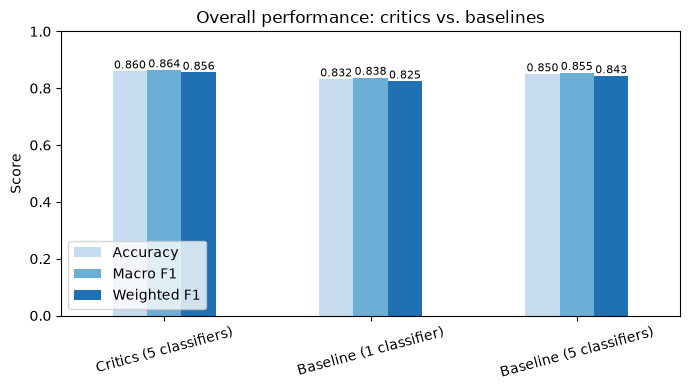

In [10]:
overall_cols = ["accuracy", "macro_f1", "weighted_f1"]
ax = run_metrics[overall_cols].astype(float).plot.bar(
    figsize=(7, 4), color=sns.color_palette("Blues", len(overall_cols)), rot=15
)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Overall performance: critics vs. baselines")
ax.legend(["Accuracy", "Macro F1", "Weighted F1"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)
plt.tight_layout()
plt.show()

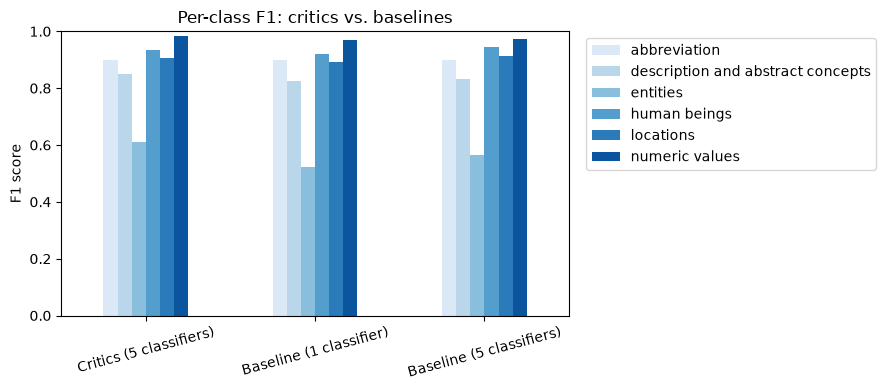

In [11]:
per_class_cols = [f"f1_{cls}" for cls in CLASS_LABELS]
ax = run_metrics[per_class_cols].astype(float).plot.bar(
    figsize=(9, 4), color=sns.color_palette("Blues", len(CLASS_LABELS)), rot=15
)
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1 score")
ax.set_title("Per-class F1: critics vs. baselines")
ax.legend(CLASS_LABELS, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()